## 1. Introduction and objectives

The first notebook produced a clean, leakage-free feature set: patient-grouped train/validation/test splits (59,605 / 19,868 / 19,867 rows), an 89-column dense/one-hot matrix for the Dense-DNN and CNN paths, and three integer diagnosis-code index arrays for an embedding path, all saved to `artifacts/`. This notebook builds, trains and evaluates the models.

A cheap logistic regression baseline is built first, then the two required architectures are built and compared against it - if a multi-layer network cannot beat a linear model, that is worth knowing.

**Models:**
1. Logistic regression - a reference point.
2. Model A - Dense DNN on the 89-feature matrix.
3. Model B - 1D-CNN on the same matrix reshaped to `(89, 1)`.
4. Model A2 - Dense DNN with entity embeddings for `diag_1/2/3` (an ablation against Model A).

**Reading the numbers.** Published AUROC on this dataset spans an implausible 0.48-0.974; sorting studies by where resampling sits relative to the split separates them cleanly - resample-after or none gives 0.48-0.70, resample-before gives 0.95-0.974 (Section 8 reproduces this). The trustworthy state of the art is 0.58-0.61 for neural networks, 0.63-0.70 for gradient boosting, and 0.56 for LACE, the score hospitals deploy. An honestly evaluated model in the 0.58-0.65 range is a good result here, not a weak one.

**Protocol, held to for every model:**
1. The test set is touched once per model, for final reporting only, after all decisions are frozen on the validation split. It is never passed as `validation_data`.
2. Resampling happens on the training fold only, after the split - never before.
3. Everything is seeded from one `RANDOM_STATE = 42`.
4. `EarlyStopping` on validation loss with `restore_best_weights=True`, rather than a fixed epoch count.

## 2. Setup, seeds, GPU check, load artifacts

**Import required libraries**

In [1]:
# Core stack, following the own import idiom, plus the pieces already established as part of this project's pipeline
import json
import random
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.models import Sequential, Model
from keras.layers import (
    Input, Dense, Dropout, Conv1D, MaxPooling1D, SpatialDropout1D,
    Flatten, Embedding, Concatenate,
)
from keras.callbacks import EarlyStopping

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score,
)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

I0000 00:00:1784870930.320458  592354 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1784870931.324572  592354 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


**Seed everything**

One global seed, reused by NumPy, the stdlib `random` module, TensorFlow's generator, and every `random_state=` argument below.

In [2]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Resolve the project root so the notebook runs correctly whether it is launched from the project root or from inside
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

pd.set_option("display.max_columns", None)
print(f"Global RANDOM_STATE = {RANDOM_STATE}")

Global RANDOM_STATE = 42


**GPU check**

TensorFlow is checked for GPU visibility. A CPU fallback is fine at this data size - a Dense or Conv1D epoch on ~60k x 89 takes a few seconds either way.

In [3]:
gpu_devices = tf.config.list_physical_devices("GPU")
print(f"TensorFlow {tf.__version__}, Keras {tf.keras.__version__ if hasattr(tf, 'keras') else ''}")
print(f"GPUs visible: {gpu_devices if gpu_devices else 'NONE - running on CPU'}")

TensorFlow 2.21.0, Keras 3.15.0
GPUs visible: NONE - running on CPU


E0000 00:00:1784870931.773937  592354 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error


**Load the artifacts from notebook 1**

The 89-feature dense matrix (imputed, scaled, encoded and variance-pruned) drives the baseline, Model A and Model B. The three diagnosis-code index arrays drive the Model A2 embedding inputs. Everything was fit on the training fold only.

In [4]:
x_train_dense = np.load(ARTIFACTS_DIR / "x_train_dense.npy")
x_val_dense = np.load(ARTIFACTS_DIR / "x_val_dense.npy")
x_test_dense = np.load(ARTIFACTS_DIR / "x_test_dense.npy")

x_train_diag_idx = np.load(ARTIFACTS_DIR / "x_train_diag_idx.npy")
x_val_diag_idx = np.load(ARTIFACTS_DIR / "x_val_diag_idx.npy")
x_test_diag_idx = np.load(ARTIFACTS_DIR / "x_test_diag_idx.npy")

y_train = np.load(ARTIFACTS_DIR / "y_train.npy")
y_val = np.load(ARTIFACTS_DIR / "y_val.npy")
y_test = np.load(ARTIFACTS_DIR / "y_test.npy")

with open(ARTIFACTS_DIR / "manifest.json") as f:
    manifest = json.load(f)

n_features = x_train_dense.shape[1]
diag_vocab_sizes = manifest["diag_vocab_sizes"]

print(f"Dense path   -> train {x_train_dense.shape}, val {x_val_dense.shape}, test {x_test_dense.shape}")
print(f"Diag-idx path -> train {x_train_diag_idx.shape}, val {x_val_diag_idx.shape}, test {x_test_diag_idx.shape}")
print(f"Positive rate -> train {y_train.mean()*100:.2f}%, val {y_val.mean()*100:.2f}%, test {y_test.mean()*100:.2f}%")
print(f"Diagnosis vocab sizes (incl. reserved 'unknown' index): {diag_vocab_sizes}")

Dense path   -> train (59605, 89), val (19868, 89), test (19867, 89)
Diag-idx path -> train (59605, 3), val (19868, 3), test (19867, 3)
Positive rate -> train 11.39%, val 11.39%, test 11.39%
Diagnosis vocab sizes (incl. reserved 'unknown' index): {'diag_1': 671, 'diag_2': 682, 'diag_3': 733}


**Shared evaluation helpers**

Defined once and reused by every model. Alongside the usual accuracy and confusion matrix, they report ROC-AUC, PR-AUC and minority-class precision/recall/F1 - at an 11.39% positive rate the class-averaged F1 that `classification_report` prints is dominated by the majority class and misleading on its own.

In [5]:
def print_taught_evaluation_block(y_true: np.ndarray, y_pred: np.ndarray, model_name: str = "Model") -> None:
    """Print the canonical evaluation block."""
    print(f"===== {model_name}: taught evaluation block (threshold = 0.5) =====")
    print("Accuracy: ", accuracy_score(y_true, y_pred))
    print("\nConfusion Matrix: \n", confusion_matrix(y_true, y_pred))
    print("\nclassification_report: \n", classification_report(y_true, y_pred))

def compute_extended_metrics(y_true: np.ndarray, y_proba: np.ndarray, threshold: float = 0.5) -> dict:
    """Compute the metrics the does not teach, at a given threshold."""
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "minority_f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "minority_precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "minority_recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "threshold": threshold,
    }

def plot_roc_pr_curves(y_true: np.ndarray, y_proba: np.ndarray, model_name: str) -> None:
    """Plot ROC and Precision-Recall curves side by side."""
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].plot(fpr, tpr, label=f"AUROC = {roc_auc:.3f}", color="steelblue")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"{model_name} - ROC curve")
    axes[0].legend(loc="lower right")

    axes[1].plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}", color="darkorange")
    axes[1].axhline(y_true.mean(), linestyle="--", color="gray", label=f"Baseline = {y_true.mean():.3f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{model_name} - Precision-Recall curve")
    axes[1].legend(loc="upper right")
    plt.tight_layout()
    plt.show()

def plot_learning_curves(history, model_name: str) -> None:
    """Plot loss and accuracy learning curves, train vs validation."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history.history["loss"])
    axes[0].plot(history.history["val_loss"])
    axes[0].set_title(f"{model_name} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend(["Train", "Validation"], loc="upper right")

    axes[1].plot(history.history["accuracy"])
    axes[1].plot(history.history["val_accuracy"])
    axes[1].set_title(f"{model_name} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend(["Train", "Validation"], loc="lower right")
    plt.tight_layout()
    plt.show()

print("Evaluation helpers defined: print_taught_evaluation_block, compute_extended_metrics, "
      "plot_roc_pr_curves, plot_learning_curves")

Evaluation helpers defined: print_taught_evaluation_block, compute_extended_metrics, plot_roc_pr_curves, plot_learning_curves


## 3. Baseline - Logistic Regression

Logistic regression is the cheapest reference point: no architecture search, seconds to train. If a Dense network cannot beat it, that is a result worth reporting rather than hiding. For context, LACE scores 0.56 AUROC on this data and gradient boosting reaches 0.63-0.70.

No resampling or class weighting is applied - it is deliberately the plainest possible model on the same 89-feature matrix, so any later difference is attributable to the model family, not the data treatment.

In [6]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(x_train_dense, y_train)

y_proba_logreg = logreg.predict_proba(x_test_dense)[:, 1]
y_pred_logreg = (y_proba_logreg >= 0.5).astype(int)

print_taught_evaluation_block(y_test, y_pred_logreg, model_name="Logistic Regression baseline")

===== Logistic Regression baseline: taught evaluation block (threshold = 0.5) =====
Accuracy:  0.8861428499521821

Confusion Matrix: 
 [[17573    31]
 [ 2231    32]]

classification_report: 
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     17604
           1       0.51      0.01      0.03      2263

    accuracy                           0.89     19867
   macro avg       0.70      0.51      0.48     19867
weighted avg       0.84      0.89      0.84     19867



**Additional metrics (ROC-AUC, PR-AUC, minority-class P/R/F1)**

Logistic Regression baseline - extended metrics (test set):
             roc_auc: 0.6554
              pr_auc: 0.2141
         minority_f1: 0.0275
  minority_precision: 0.5079
     minority_recall: 0.0141
            accuracy: 0.8861
           threshold: 0.5000


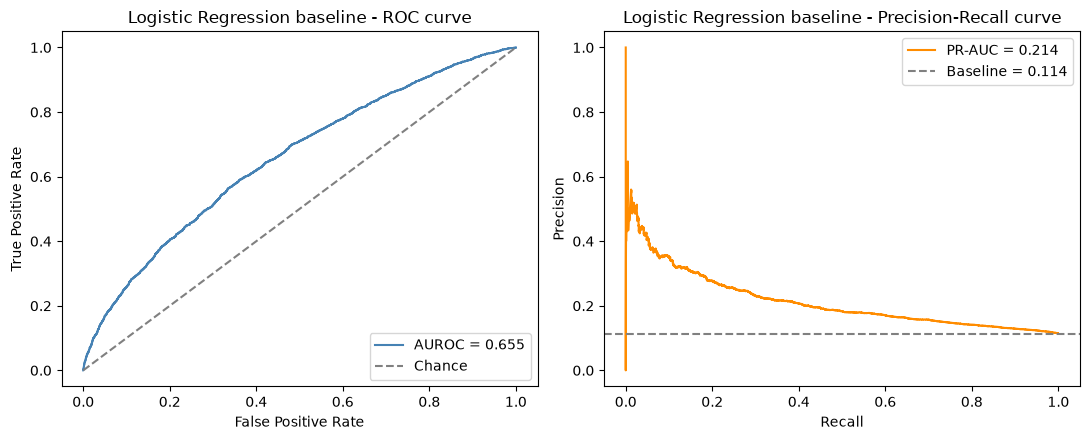

In [7]:
metrics_logreg = compute_extended_metrics(y_test, y_proba_logreg, threshold=0.5)
print("Logistic Regression baseline - extended metrics (test set):")
for key, value in metrics_logreg.items():
    print(f"  {key:>18}: {value:.4f}" if isinstance(value, float) else f"  {key:>18}: {value}")

plot_roc_pr_curves(y_test, y_proba_logreg, model_name="Logistic Regression baseline")

**Reading the baseline.** This is the number a Dense or CNN model has to beat to justify its extra complexity, and it is the first row of the results table in Section 10.

## 4. Model A - Dense DNN

A two-hidden-layer `Sequential` network: `Dense(256) -> Dropout(0.2) -> Dense(128) -> Dropout(0.2) -> Dense(1, sigmoid)`, with `he_uniform` initialisation, `binary_crossentropy` loss and the `adam` optimiser. The single sigmoid output and the loss both follow from the binary target.

Two settings differ from the small-dataset lab template and are worth noting:
- `batch_size = 256`. At 59,605 training rows a batch of 16 would mean ~3,725 steps per epoch; 256 is a better fit for this scale.
- `epochs = 50` as an upper bound with `EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)`, and monitoring `val_loss` rather than `val_accuracy` - accuracy is maximised by the all-negative predictor at 11.39% positive.

In [8]:
tf.random.set_seed(RANDOM_STATE)

classifier_a = Sequential()

# IL
# The number of neurons is equal to the number of IVs in the encoded dense matrix.
classifier_a.add(Input(shape=(n_features,)))

# HL 1
classifier_a.add(Dense(units=256, kernel_initializer="he_uniform", activation="relu"))
classifier_a.add(Dropout(0.2))

# HL 2
classifier_a.add(Dense(units=128, kernel_initializer="he_uniform", activation="relu"))
classifier_a.add(Dropout(0.2))

# OL
# Single node, sigmoid activation, since this is binary classification.
classifier_a.add(Dense(units=1, kernel_initializer="he_uniform", activation="sigmoid"))

# Compiling Neural Network
classifier_a.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

classifier_a.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        23,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,065 (219.00 KB)

 Trainable params: 56,065 (219.00 KB)

 Non-trainable params: 0 (0.00 B)

Each `fit()` step runs the standard loop: forward pass through HL1 -> HL2 -> OL to a probability, `binary_crossentropy` against the label, backpropagation of the gradient, and an `adam` weight update. `EarlyStopping` halts once `val_loss` stops improving for 5 epochs and restores the best epoch's weights.

In [9]:
early_stopping_a = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

t0 = time.time()
history_a = classifier_a.fit(
    x_train_dense, y_train,
    validation_data=(x_val_dense, y_val),  # validation only - x_test is never passed here
    batch_size=256,
    epochs=50,
    callbacks=[early_stopping_a],
    verbose=2,
)
print(f"\nModel A trained for {len(history_a.history['loss'])} epochs in {time.time() - t0:.1f}s "
      f"(EarlyStopping patience = 5, restore_best_weights = True)")

Epoch 1/50


233/233 - 1s - 5ms/step - accuracy: 0.8853 - loss: 0.3524 - val_accuracy: 0.8865 - val_loss: 0.3402


Epoch 2/50


233/233 - 1s - 2ms/step - accuracy: 0.8859 - loss: 0.3410 - val_accuracy: 0.8861 - val_loss: 0.3383


Epoch 3/50


...

Epoch 9/50


233/233 - 1s - 2ms/step - accuracy: 0.8874 - loss: 0.3263 - val_accuracy: 0.8861 - val_loss: 0.3388


Epoch 10/50


233/233 - 0s - 2ms/step - accuracy: 0.8872 - loss: 0.3237 - val_accuracy: 0.8860 - val_loss: 0.3396



Model A trained for 10 epochs in 5.9s (EarlyStopping patience = 5, restore_best_weights = True)


**Sampled training log** - first and last two epochs (the full `verbose=2` log ran above).

In [10]:
hist_df_a = pd.DataFrame(history_a.history)
hist_df_a.index.name = "epoch"
pd.concat([hist_df_a.head(2), hist_df_a.tail(2)])

,accuracy,loss,val_accuracy,val_loss
epoch,,,,
0,0.885278,0.352434,0.886501,0.340249
1,0.885865,0.341001,0.886098,0.338345
8,0.887409,0.326341,0.886149,0.338805
9,0.887157,0.323715,0.886048,0.339636


**Learning curves**

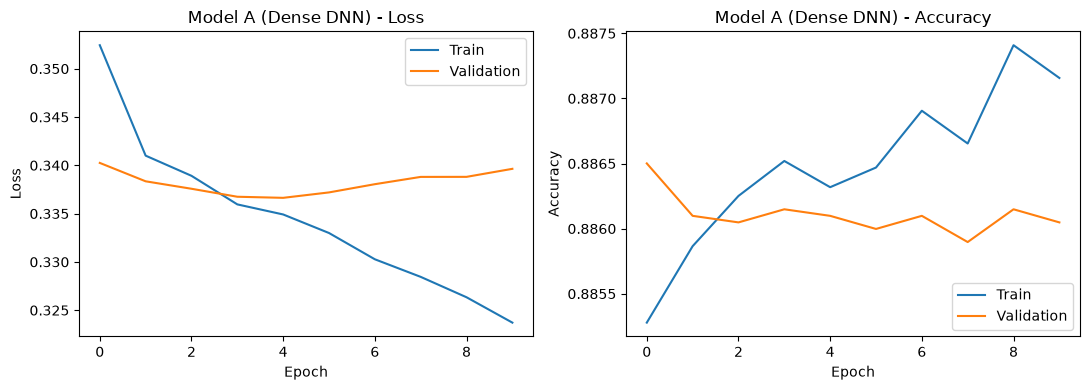

In [11]:
plot_learning_curves(history_a, model_name="Model A (Dense DNN)")

**Fit diagnosis and convergence.** Training and validation loss falling together indicates a good fit; validation loss rising while training loss keeps falling would indicate overfitting. Convergence is read off the same plot - once validation loss flattens, `EarlyStopping` has already stopped training near that point.

### 4.1 Model A - Evaluation

**Evaluation at threshold 0.5**

In [12]:
y_proba_a = classifier_a.predict(x_test_dense, verbose=0).ravel()
y_pred_a = (y_proba_a >= 0.5).astype(int)

print_taught_evaluation_block(y_test, y_pred_a, model_name="Model A (Dense DNN)")

===== Model A (Dense DNN): taught evaluation block (threshold = 0.5) =====
Accuracy:  0.8862938541299643

Confusion Matrix: 
 [[17599     5]
 [ 2254     9]]

classification_report: 
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     17604
           1       0.64      0.00      0.01      2263

    accuracy                           0.89     19867
   macro avg       0.76      0.50      0.47     19867
weighted avg       0.86      0.89      0.83     19867



**Metrics not shown by the default report.** At 11.39% positive the model predicts mostly negative at the 0.5 threshold (addressed in Section 7); ROC-AUC and PR-AUC are threshold-independent and are the numbers compared against the literature.

Model A - extended metrics (test set, threshold = 0.5):
             roc_auc: 0.6627
              pr_auc: 0.2174
         minority_f1: 0.0079
  minority_precision: 0.6429
     minority_recall: 0.0040
            accuracy: 0.8863
           threshold: 0.5000


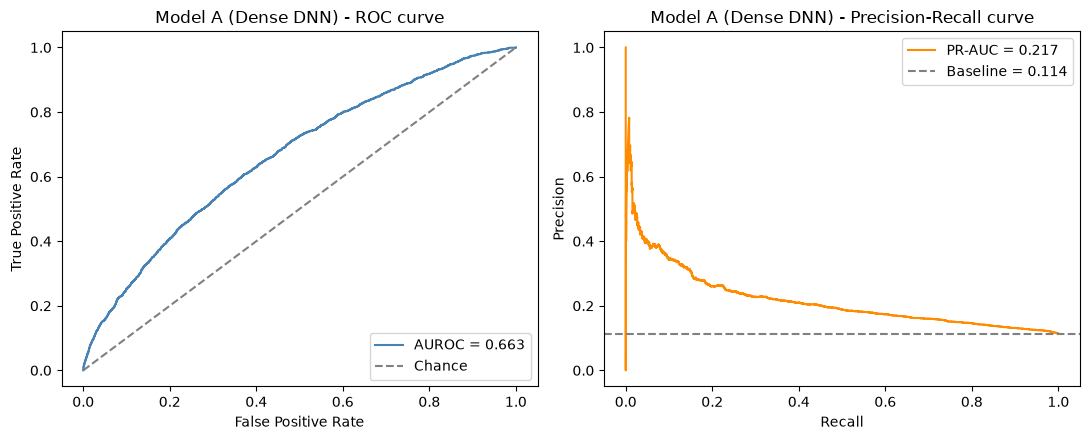

In [13]:
metrics_a = compute_extended_metrics(y_test, y_proba_a, threshold=0.5)
print("Model A - extended metrics (test set, threshold = 0.5):")
for key, value in metrics_a.items():
    print(f"  {key:>18}: {value:.4f}" if isinstance(value, float) else f"  {key:>18}: {value}")

plot_roc_pr_curves(y_test, y_proba_a, model_name="Model A (Dense DNN)")

## 5. Model B - 1D-CNN

A `Conv1D` classifier on the same matrix reshaped to `(89, 1)`: two `Conv1D -> SpatialDropout1D(0.2) -> MaxPooling1D(2)` blocks, then `Flatten -> Dense(128) -> Dropout(0.2) -> Dense(1, sigmoid)`.

Applying a 1D convolution to tabular data is a recognised construction, but it carries an assumption this data does not satisfy: a convolution treats neighbouring positions as related and pools over a small window, whereas the 89 columns have no meaningful order - column 12 sits next to column 13 only because of how the `ColumnTransformer` concatenated the blocks. This locality prior is not justified here a priori, which is the reason Model B is built and tested rather than assumed to help; the comparison against Model A in Section 10 gives the answer.

In [14]:
# The (n, k, 1) reshape that makes the tabular dense matrix Conv1D-able
# one "channel" per row, 89 positions.
x_train_cnn = x_train_dense.reshape(-1, n_features, 1)
x_val_cnn = x_val_dense.reshape(-1, n_features, 1)
x_test_cnn = x_test_dense.reshape(-1, n_features, 1)

print(f"CNN input shapes -> train {x_train_cnn.shape}, val {x_val_cnn.shape}, test {x_test_cnn.shape}")

CNN input shapes -> train (59605, 89, 1), val (19868, 89, 1), test (19867, 89, 1)


In [15]:
tf.random.set_seed(RANDOM_STATE)

model_cnn = Sequential()
model_cnn.add(Input(shape=(n_features, 1)))

# CNN layer 1 with Pooling
model_cnn.add(Conv1D(filters=64, kernel_size=2, activation="relu"))
model_cnn.add(SpatialDropout1D(0.2))
model_cnn.add(MaxPooling1D(pool_size=2))

# CNN layer 2 with Pooling
model_cnn.add(Conv1D(filters=128, kernel_size=2, activation="relu"))
model_cnn.add(SpatialDropout1D(0.2))
model_cnn.add(MaxPooling1D(pool_size=2))

# Flatten layer
model_cnn.add(Flatten())

# Fully connected Layer
model_cnn.add(Dense(128, activation="relu"))
model_cnn.add(Dropout(0.2))

# Output Layer
model_cnn.add(Dense(1, activation="sigmoid"))

# model compile
model_cnn.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 88, 64)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 88, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 44, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 43, 128)        │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 43, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2688)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       344,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,025 (1.38 MB)

 Trainable params: 361,025 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
early_stopping_cnn = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

t0 = time.time()
# Fit the model
history_cnn = model_cnn.fit(
    x_train_cnn, y_train,
    validation_data=(x_val_cnn, y_val),  # validation only - never x_test
    batch_size=256,
    epochs=50,
    callbacks=[early_stopping_cnn],
    verbose=2,
)
print(f"\nModel B trained for {len(history_cnn.history['loss'])} epochs in {time.time() - t0:.1f}s")

Epoch 1/50


233/233 - 3s - 15ms/step - accuracy: 0.8845 - loss: 0.3487 - val_accuracy: 0.8861 - val_loss: 0.3435


Epoch 2/50


233/233 - 3s - 11ms/step - accuracy: 0.8861 - loss: 0.3426 - val_accuracy: 0.8860 - val_loss: 0.3391


Epoch 3/50


...

Epoch 24/50


233/233 - 3s - 11ms/step - accuracy: 0.8866 - loss: 0.3333 - val_accuracy: 0.8859 - val_loss: 0.3380


Epoch 25/50


233/233 - 3s - 11ms/step - accuracy: 0.8869 - loss: 0.3329 - val_accuracy: 0.8860 - val_loss: 0.3380



Model B trained for 25 epochs in 67.7s


**Sampled training log**

In [17]:
hist_df_cnn = pd.DataFrame(history_cnn.history)
hist_df_cnn.index.name = "epoch"
pd.concat([hist_df_cnn.head(2), hist_df_cnn.tail(2)])

,accuracy,loss,val_accuracy,val_loss
epoch,,,,
0,0.884523,0.348723,0.886098,0.343532
1,0.886117,0.342603,0.886048,0.339079
23,0.886570,0.333326,0.885897,0.337989
24,0.886855,0.332930,0.885998,0.338030


**Learning curves**

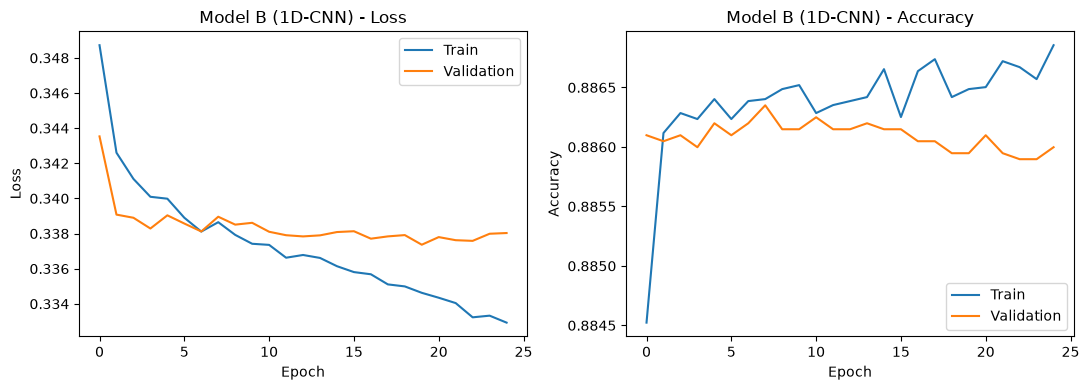

In [18]:
plot_learning_curves(history_cnn, model_name="Model B (1D-CNN)")

### 5.1 Model B - Evaluation

**Evaluation at threshold 0.5**

In [19]:
y_pred_cnn_proba = model_cnn.predict(x_test_cnn, verbose=0)
y_proba_cnn = y_pred_cnn_proba.ravel()
y_pred_cnn = y_pred_cnn_proba.round().astype(int).ravel()

print_taught_evaluation_block(y_test, y_pred_cnn, model_name="Model B (1D-CNN)")

===== Model B (1D-CNN): taught evaluation block (threshold = 0.5) =====
Accuracy:  0.8860421805003271

Confusion Matrix: 
 [[17597     7]
 [ 2257     6]]

classification_report: 
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     17604
           1       0.46      0.00      0.01      2263

    accuracy                           0.89     19867
   macro avg       0.67      0.50      0.47     19867
weighted avg       0.84      0.89      0.83     19867



Model B - extended metrics (test set, threshold = 0.5):
             roc_auc: 0.6635
              pr_auc: 0.2155
         minority_f1: 0.0053
  minority_precision: 0.4615
     minority_recall: 0.0027
            accuracy: 0.8860
           threshold: 0.5000


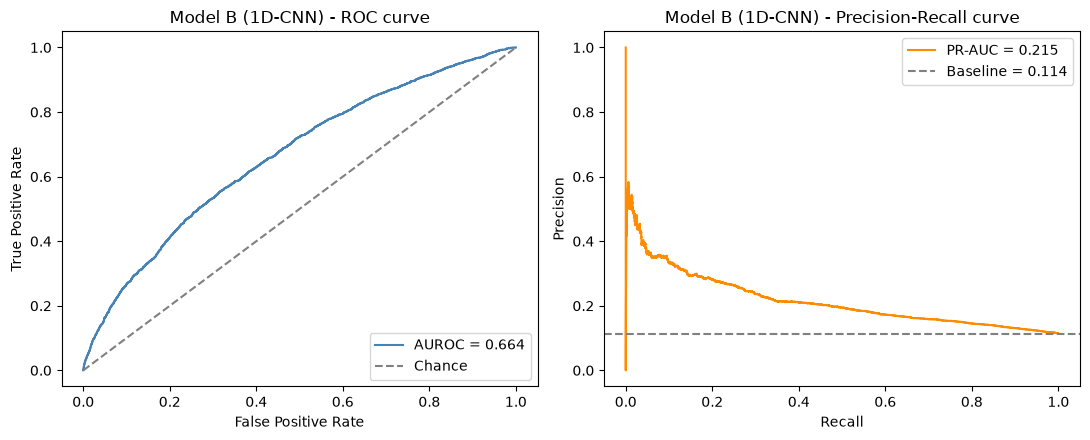

In [20]:
metrics_cnn = compute_extended_metrics(y_test, y_proba_cnn, threshold=0.5)
print("Model B - extended metrics (test set, threshold = 0.5):")
for key, value in metrics_cnn.items():
    print(f"  {key:>18}: {value:.4f}" if isinstance(value, float) else f"  {key:>18}: {value}")

plot_roc_pr_curves(y_test, y_proba_cnn, model_name="Model B (1D-CNN)")

**Reading Model B.** Section 10 places Model A and Model B side by side on identical data and protocol; the difference between them is the empirical answer to whether the locality prior helped, hurt, or made no practical difference.

## 6. Model A2 - Dense DNN + entity embeddings (ablation)

Model A one-hot encodes the ~9-level clinical diagnosis categories inside the 89-feature matrix. Model A2 instead feeds the raw high-cardinality ICD-9 codes (671 / 682 / 733 distinct levels) through a learned embedding per diagnosis slot, concatenated with the same 89 dense features. This is the architecture Sarthak et al. (2020) used; their published 0.974 AUROC, however, comes from resampling the whole dataset before splitting (Section 8), not from the embeddings. Model A2 isolates the embeddings question on its own.

The `Sequential` API takes one input tensor, so this model needs the Functional API: four inputs - the 89-dim dense vector plus three integer diagnosis codes, each through its own `Embedding` table before concatenation.

In [21]:
tf.random.set_seed(RANDOM_STATE)

EMBEDDING_DIM = 8  # small relative to vocab size (671-733); kept modest given ~60k training rows

dense_input = Input(shape=(n_features,), name="dense_input")

diag_inputs = []
diag_embeddings = []
for diag_col in ("diag_1", "diag_2", "diag_3"):
    diag_input = Input(shape=(1,), name=f"{diag_col}_input")
    embedding = Embedding(
        input_dim=diag_vocab_sizes[diag_col],
        output_dim=EMBEDDING_DIM,
        name=f"{diag_col}_embedding",
    )(diag_input)
    embedding = Flatten()(embedding)
    diag_inputs.append(diag_input)
    diag_embeddings.append(embedding)

# Concatenate the 87 dense features with the three flattened diagnosis embeddings
merged = Concatenate()([dense_input] + diag_embeddings)

# HL 1 / HL 2 - same funnel width as Model A, so any difference in results
# below is attributable to the embeddings, not to a wider/narrower network.
hidden = Dense(units=256, kernel_initializer="he_uniform", activation="relu")(merged)
hidden = Dropout(0.2)(hidden)
hidden = Dense(units=128, kernel_initializer="he_uniform", activation="relu")(hidden)
hidden = Dropout(0.2)(hidden)

# OL
output = Dense(units=1, kernel_initializer="he_uniform", activation="sigmoid")(hidden)

model_a2 = Model(inputs=[dense_input] + diag_inputs, outputs=output, name="model_a2_embeddings")
model_a2.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_a2.summary()

Model: "model_a2_embeddings"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ diag_1_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_2_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_3_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_1_embedding    │ (None, 1, 8)      │      5,368 │ diag_1_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_2_embedding    │ (None, 1, 8)      │      5,456 │ diag_2_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_3_embedding    │ (None, 1, 8)      │      5,864 │ diag_3_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_input         │ (None, 89)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 8)         │          0 │ diag_1_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 8)         │          0 │ diag_2_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 8)         │          0 │ diag_3_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 113)       │          0 │ dense_input[0][0… │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │     29,184 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     32,896 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │        129 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 78,897 (308.19 KB)

 Trainable params: 78,897 (308.19 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
train_inputs_a2 = [x_train_dense, x_train_diag_idx[:, 0], x_train_diag_idx[:, 1], x_train_diag_idx[:, 2]]
val_inputs_a2 = [x_val_dense, x_val_diag_idx[:, 0], x_val_diag_idx[:, 1], x_val_diag_idx[:, 2]]
test_inputs_a2 = [x_test_dense, x_test_diag_idx[:, 0], x_test_diag_idx[:, 1], x_test_diag_idx[:, 2]]

early_stopping_a2 = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

t0 = time.time()
history_a2 = model_a2.fit(
    train_inputs_a2, y_train,
    validation_data=(val_inputs_a2, y_val),
    batch_size=256,
    epochs=50,
    callbacks=[early_stopping_a2],
    verbose=2,
)
print(f"\nModel A2 trained for {len(history_a2.history['loss'])} epochs in {time.time() - t0:.1f}s")

Epoch 1/50


233/233 - 2s - 8ms/step - accuracy: 0.8851 - loss: 0.3505 - val_accuracy: 0.8862 - val_loss: 0.3398


Epoch 2/50


233/233 - 1s - 2ms/step - accuracy: 0.8863 - loss: 0.3391 - val_accuracy: 0.8861 - val_loss: 0.3397


Epoch 3/50


...

Epoch 6/50


233/233 - 1s - 2ms/step - accuracy: 0.8870 - loss: 0.3192 - val_accuracy: 0.8863 - val_loss: 0.3479


Epoch 7/50


233/233 - 1s - 2ms/step - accuracy: 0.8873 - loss: 0.3157 - val_accuracy: 0.8863 - val_loss: 0.3503



Model A2 trained for 7 epochs in 5.4s


**Learning curves**

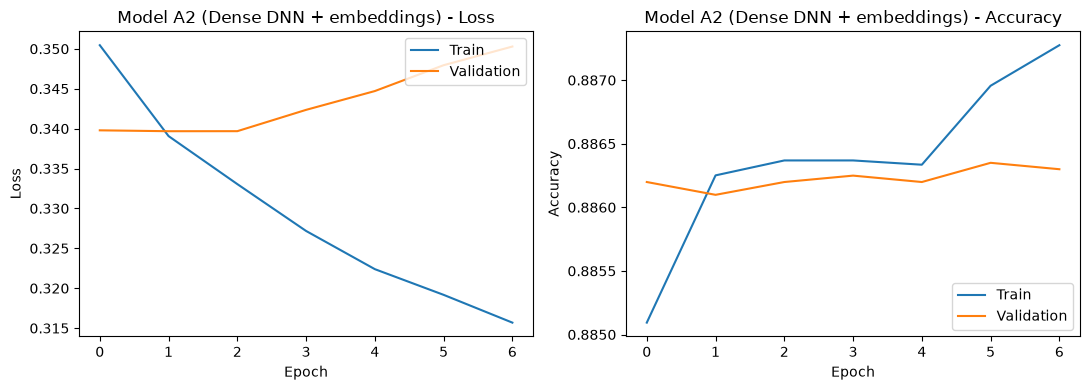

In [23]:
plot_learning_curves(history_a2, model_name="Model A2 (Dense DNN + embeddings)")

### 6.1 Model A2 - Evaluation

In [24]:
y_proba_a2 = model_a2.predict(test_inputs_a2, verbose=0).ravel()
y_pred_a2 = (y_proba_a2 >= 0.5).astype(int)

print_taught_evaluation_block(y_test, y_pred_a2, model_name="Model A2 (Dense DNN + embeddings)")

===== Model A2 (Dense DNN + embeddings): taught evaluation block (threshold = 0.5) =====
Accuracy:  0.88579050687069

Confusion Matrix: 
 [[17588    16]
 [ 2253    10]]

classification_report: 
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     17604
           1       0.38      0.00      0.01      2263

    accuracy                           0.89     19867
   macro avg       0.64      0.50      0.47     19867
weighted avg       0.83      0.89      0.83     19867



In [25]:
metrics_a2 = compute_extended_metrics(y_test, y_proba_a2, threshold=0.5)
print("Model A2 - extended metrics (test set, threshold = 0.5):")
for key, value in metrics_a2.items():
    print(f"  {key:>18}: {value:.4f}" if isinstance(value, float) else f"  {key:>18}: {value}")

Model A2 - extended metrics (test set, threshold = 0.5):
             roc_auc: 0.6633
              pr_auc: 0.2117
         minority_f1: 0.0087
  minority_precision: 0.3846
     minority_recall: 0.0044
            accuracy: 0.8858
           threshold: 0.5000


**Do the embeddings help? Model A vs Model A2, otherwise identical:**

In [26]:
embedding_ablation = pd.DataFrame([
    {"model": "Model A (one-hot diag category)", **compute_extended_metrics(y_test, y_proba_a)},
    {"model": "Model A2 (learned diag embeddings)", **compute_extended_metrics(y_test, y_proba_a2)},
]).set_index("model")[["roc_auc", "pr_auc", "minority_f1", "accuracy"]]

embedding_ablation.round(4)

,roc_auc,pr_auc,minority_f1,accuracy
model,,,,
Model A (one-hot diag category),0.6627,0.2174,0.0079,0.8863
Model A2 (learned diag embeddings),0.6633,0.2117,0.0087,0.8858


**Reading the ablation.** A2 beating A would support the usual claim that a learned dense representation of a high-cardinality code captures more than a coarse grouping. A flat or negative result is equally worth reporting: it would suggest the ~9-category grouping already captures most of the signal a 59,605-row training fold can support, and the extra embedding parameters are not earning their keep.

## 7. Threshold analysis

Every evaluation so far used the default 0.5 cut-off to turn a probability into a label. At 11.39% positive that is a poor choice: the all-negative predictor already scores ~88.6% accuracy, so a model only slightly better than chance can push almost every prediction below 0.5 and still look accurate. This section selects a better operating point.

The threshold is chosen on the validation set only, by two standard criteria - max-F1 on the precision-recall curve, and Youden's J (max `TPR - FPR`) on the ROC curve - then applied to the test set and compared against 0.5.

In [27]:
def select_threshold_max_f1(y_true_val: np.ndarray, y_proba_val: np.ndarray) -> float:
    """Select the probability threshold that maximises F1 on the validation PR curve."""
    precision, recall, thresholds = precision_recall_curve(y_true_val, y_proba_val)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-12)
    # precision/recall have one more element than thresholds (the (1, 0) endpoint) - drop it
    best_idx = np.argmax(f1_scores[:-1])
    return float(thresholds[best_idx])

def select_threshold_youden_j(y_true_val: np.ndarray, y_proba_val: np.ndarray) -> float:
    """Select the probability threshold maximising Youden's J (TPR - FPR) on validation."""
    fpr, tpr, thresholds = roc_curve(y_true_val, y_proba_val)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    return float(thresholds[best_idx])

def threshold_comparison_table(y_true_test: np.ndarray, y_proba_test: np.ndarray, chosen_threshold: float) -> pd.DataFrame:
    '''Build a side-by-side metrics table at the default 0.5 vs a chosen threshold.'''
    rows = []
    for label, threshold in [("Default (0.5)", 0.5), ("Validation-selected", chosen_threshold)]:
        row = compute_extended_metrics(y_true_test, y_proba_test, threshold=threshold)
        row["operating_point"] = label
        rows.append(row)
    return pd.DataFrame(rows).set_index("operating_point")[
        ["threshold", "accuracy", "minority_precision", "minority_recall", "minority_f1", "roc_auc", "pr_auc"]
    ]

### 7.1 Model A

In [28]:
y_proba_a_val = classifier_a.predict(x_val_dense, verbose=0).ravel()

threshold_a_f1 = select_threshold_max_f1(y_val, y_proba_a_val)
threshold_a_j = select_threshold_youden_j(y_val, y_proba_a_val)
print(f"Model A - validation-selected threshold (max-F1):    {threshold_a_f1:.4f}")
print(f"Model A - validation-selected threshold (Youden's J): {threshold_a_j:.4f}")

print("\nModel A - test-set metrics, default vs max-F1 threshold:")
threshold_comparison_table(y_test, y_proba_a, threshold_a_f1).round(4)

Model A - validation-selected threshold (max-F1):    0.1532
Model A - validation-selected threshold (Youden's J): 0.1170

Model A - test-set metrics, default vs max-F1 threshold:


,threshold,accuracy,minority_precision,minority_recall,minority_f1,roc_auc,pr_auc
operating_point,,,,,,,
Default (0.5),0.5000,0.8863,0.6429,0.0040,0.0079,0.6627,0.2174
Validation-selected,0.1532,0.7464,0.2042,0.4233,0.2755,0.6627,0.2174


In [29]:
y_pred_a_thresh = (y_proba_a >= threshold_a_f1).astype(int)
print(f"Model A - confusion matrix at the validation-selected threshold ({threshold_a_f1:.4f}):")
print(confusion_matrix(y_test, y_pred_a_thresh))
print(f"\nFor comparison, at the default 0.5 threshold:")
print(confusion_matrix(y_test, y_pred_a))

Model A - confusion matrix at the validation-selected threshold (0.1532):
[[13870  3734]
 [ 1305   958]]

For comparison, at the default 0.5 threshold:
[[17599     5]
 [ 2254     9]]


### 7.2 Model B

In [30]:
y_proba_cnn_val = model_cnn.predict(x_val_cnn, verbose=0).ravel()

threshold_cnn_f1 = select_threshold_max_f1(y_val, y_proba_cnn_val)
print(f"Model B - validation-selected threshold (max-F1): {threshold_cnn_f1:.4f}")

print("\nModel B - test-set metrics, default vs max-F1 threshold:")
threshold_comparison_table(y_test, y_proba_cnn, threshold_cnn_f1).round(4)

Model B - validation-selected threshold (max-F1): 0.1433

Model B - test-set metrics, default vs max-F1 threshold:


,threshold,accuracy,minority_precision,minority_recall,minority_f1,roc_auc,pr_auc
operating_point,,,,,,,
Default (0.5),0.5000,0.8860,0.4615,0.0027,0.0053,0.6635,0.2155
Validation-selected,0.1433,0.7273,0.2011,0.4688,0.2815,0.6635,0.2155


### 7.3 Logistic Regression and Model A2 (thresholds, for persistence)

The same validation-selected max-F1 threshold applied to the baseline and the stretch model, so every model in Section 10 has a tuned threshold saved alongside it. The reading is the same as for Models A and B above.

In [31]:
y_proba_logreg_val = logreg.predict_proba(x_val_dense)[:, 1]
threshold_logreg_f1 = select_threshold_max_f1(y_val, y_proba_logreg_val)
print(f"Logistic Regression - validation-selected threshold (max-F1): {threshold_logreg_f1:.4f}")

y_proba_a2_val = model_a2.predict(val_inputs_a2, verbose=0).ravel()
threshold_a2_f1 = select_threshold_max_f1(y_val, y_proba_a2_val)
print(f"Model A2 - validation-selected threshold (max-F1): {threshold_a2_f1:.4f}")

Logistic Regression - validation-selected threshold (max-F1): 0.1310


Model A2 - validation-selected threshold (max-F1): 0.1572


**Reading the threshold analysis.** The 0.5 row typically shows high accuracy with low minority recall - the model is quietly predicting "not readmitted" for almost everyone, which is clinically useless despite the flattering accuracy. The validation-selected threshold trades some accuracy for materially better minority recall and F1, which is the trade that matters for a screening tool: a missed readmission costs more than one extra follow-up call. ROC-AUC and PR-AUC are threshold-independent and unchanged between the rows.

## 8. The 2x2 experiment - resampling placement x split method

This is the most important section in the notebook. Reported AUROC on this dataset spans 0.48 to 0.974, and sorting studies by a single variable - whether resampling happens before or after the split - separates them cleanly: resample-after or none gives 0.48-0.70, resample-before gives 0.95-0.974. Sarthak et al. (2020), architecturally close to Model A2, resample the entire dataset to 1:1 before cross-validation and report 0.974. We run our own pipeline all four ways to test this directly.

| | Resample in-fold only | Resample before split |
|---|---|---|
| **Patient-grouped split** | (a) our honest protocol | (d) |
| **Naive random split** | (b) | (c) replicates the published method |

Same Dense architecture, seed and training protocol across all four cells; only the two axes vary. Cell (a) should land close to the main Model A result as a consistency check.

Resampling before the split does two separate things, and the experiment separates them. It leaks information across train/test, and it also changes what the test set measures: balancing the whole pool to 1:1 before splitting leaves the test partition ~50% positive rather than the real ~11.39%, so PR-AUC in particular (whose baseline is the positive rate) is measured on a different, easier problem. Cells (c') and (d') re-score the same trained models on the real (non-synthetic) test rows only, restoring the true prevalence. Comparing (c) -> (c') -> (a) splits the total gap into an evaluation-population component and a genuine-leakage component.

The pre-split cleaned frame (99,340 rows) is re-derived below by repeating notebook 1's before-split cleaning, since `artifacts/` only holds the post-split encoded arrays.

**Re-derive the pre-split cleaned frame (repeats Notebook 1 Section 5)**

In [32]:
def build_pre_split_frame() -> pd.DataFrame:
    """Repeat documented before-split cleaning, exactly."""
    data = pd.read_csv(DATA_DIR / "diabetic_data.csv", na_values="?", low_memory=False)

    columns_to_drop = ["encounter_id", "examide", "citoglipton", "weight", "medical_specialty", "payer_code"]
    data = data.drop(columns=columns_to_drop)

    expired_hospice_ids = [11, 13, 14, 19, 20, 21]
    data = data[~data["discharge_disposition_id"].isin(expired_hospice_ids)].copy()
    data = data[data["gender"] != "Unknown/Invalid"].copy()

    age_bin_to_midpoint = {
        "[0-10)": 5, "[10-20)": 15, "[20-30)": 25, "[30-40)": 35, "[40-50)": 45,
        "[50-60)": 55, "[60-70)": 65, "[70-80)": 75, "[80-90)": 85, "[90-100)": 95,
    }
    data["age"] = data["age"].map(age_bin_to_midpoint)

    from io import StringIO
    with open(DATA_DIR / "IDS_mapping.csv") as f:
        raw_lines = f.readlines()
    separator_idx = [i for i, line in enumerate(raw_lines) if line.strip() in ("", ",")]
    table_bounds = [0] + [i + 1 for i in separator_idx] + [len(raw_lines)]
    table_names = ["admission_type_id", "discharge_disposition_id", "admission_source_id"]
    id_maps = {}
    for name, start, end in zip(table_names, table_bounds[:-1], table_bounds[1:]):
        chunk_lines = [ln for ln in raw_lines[start:end] if ln.strip() not in ("", ",")]
        lookup_table = pd.read_csv(StringIO("".join(chunk_lines)))
        id_maps[name] = dict(zip(lookup_table[name], lookup_table["description"]))
    for id_col, description_col in [
        ("admission_type_id", "admission_type"),
        ("discharge_disposition_id", "discharge_disposition"),
        ("admission_source_id", "admission_source"),
    ]:
        data[description_col] = data[id_col].map(id_maps[id_col])
    data = data.drop(columns=["admission_type_id", "discharge_disposition_id", "admission_source_id"])

    def icd9_to_category(code) -> str:
        if pd.isna(code):
            return "Missing"
        code = str(code)
        if code.startswith("V") or code.startswith("E"):
            return "Other"
        try:
            value = float(code)
        except ValueError:
            return "Other"
        if 390 <= value <= 459 or value == 785:
            return "Circulatory"
        if 460 <= value <= 519 or value == 786:
            return "Respiratory"
        if 520 <= value <= 579 or value == 787:
            return "Digestive"
        if 250 <= value < 251:
            return "Diabetes"
        if 800 <= value <= 999:
            return "Injury"
        if 710 <= value <= 739:
            return "Musculoskeletal"
        if 580 <= value <= 629 or value == 788:
            return "Genitourinary"
        if 140 <= value <= 239:
            return "Neoplasms"
        return "Other"

    for diag_col in ("diag_1", "diag_2", "diag_3"):
        data[f"{diag_col}_category"] = data[diag_col].apply(icd9_to_category)
        data[diag_col] = data[diag_col].fillna("Missing")

    data["readmitted_30d"] = (data["readmitted"] == "<30").astype(int)
    data = data.drop(columns=["readmitted"] + ["diag_1", "diag_2", "diag_3"])
    return data

pre_split_frame = build_pre_split_frame()
assert pre_split_frame.shape[0] == 99340, f"Expected 99,340 rows, got {pre_split_frame.shape[0]}"
print(f"Pre-split cleaned frame reproduced: {pre_split_frame.shape} (assertion passed: 99,340 rows)")

Pre-split cleaned frame reproduced: (99340, 44) (assertion passed: 99,340 rows)


**Shared helpers: splitting, encoding, and group-aware resampling**

In [33]:
numeric_features_2x2 = [
    "age", "time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
    "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses",
]
medication_features_2x2 = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "insulin", "glyburide-metformin", "glipizide-metformin",
    "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone",
]
categorical_features_2x2 = [
    "race", "gender", "admission_type", "discharge_disposition", "admission_source",
    "max_glu_serum", "A1Cresult", "change", "diabetesMed",
    "diag_1_category", "diag_2_category", "diag_3_category",
] + medication_features_2x2

def make_grouped_split_2x2(df: pd.DataFrame, random_state: int):
    '''Patient-grouped, stratified 60/20/20 split (Notebook 1 Section 6's method, reused).'''
    x_all = df.drop(columns=["readmitted_30d"])
    y_all = df["readmitted_30d"]
    groups_all = df["patient_nbr"]

    splitter_test = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=random_state)
    train_val_idx, test_idx = next(splitter_test.split(x_all, y_all, groups_all))

    x_tv, y_tv, g_tv = x_all.iloc[train_val_idx], y_all.iloc[train_val_idx], groups_all.iloc[train_val_idx]
    splitter_val = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=random_state)
    train_idx_local, val_idx_local = next(splitter_val.split(x_tv, y_tv, g_tv))
    train_idx = train_val_idx[train_idx_local]
    val_idx = train_val_idx[val_idx_local]

    return (
        x_all.iloc[train_idx].reset_index(drop=True), y_all.iloc[train_idx].reset_index(drop=True),
        x_all.iloc[val_idx].reset_index(drop=True), y_all.iloc[val_idx].reset_index(drop=True),
        x_all.iloc[test_idx].reset_index(drop=True), y_all.iloc[test_idx].reset_index(drop=True),
    )

def make_naive_split_2x2(df: pd.DataFrame, random_state: int):
    '''Naive random, stratified (but NOT grouped) 60/20/20 split - patients may span splits.'''
    x_all = df.drop(columns=["readmitted_30d"])
    y_all = df["readmitted_30d"]

    x_tv, x_test, y_tv, y_test_ = train_test_split(
        x_all, y_all, test_size=0.2, stratify=y_all, random_state=random_state
    )
    x_tr, x_va, y_tr, y_va = train_test_split(
        x_tv, y_tv, test_size=0.25, stratify=y_tv, random_state=random_state
    )
    return (
        x_tr.reset_index(drop=True), y_tr.reset_index(drop=True),
        x_va.reset_index(drop=True), y_va.reset_index(drop=True),
        x_test.reset_index(drop=True), y_test_.reset_index(drop=True),
    )

def encode_dense_2x2(x_fit: pd.DataFrame, frames_to_transform: list):
    """Fit a ColumnTransformer (impute+scale numeric, impute+one-hot categorical) on x_fit only."""
    numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="mean")), ("scaler", StandardScaler())])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    preprocessor = ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features_2x2),
        ("categorical", categorical_pipeline, categorical_features_2x2),
    ])
    cols = numeric_features_2x2 + categorical_features_2x2
    encoded = [preprocessor.fit_transform(x_fit[cols]).astype("float32")]
    for frame in frames_to_transform:
        encoded.append(preprocessor.transform(frame[cols]).astype("float32"))
    return encoded

def smote_with_groups(x_enc: np.ndarray, y_arr: np.ndarray, groups_arr: np.ndarray, random_state: int):
    """Apply SMOTE while preserving a group array for the appended synthetic rows."""
    n_original = len(y_arr)
    x_res, y_res = SMOTE(random_state=random_state).fit_resample(x_enc, y_arr)
    n_synthetic = len(y_res) - n_original
    synthetic_groups = -1 * (np.arange(n_synthetic) + 1)
    groups_res = np.concatenate([np.asarray(groups_arr), synthetic_groups])
    return x_res, y_res, groups_res

def build_2x2_model(input_dim: int) -> Sequential:
    '''Build the fixed Dense architecture shared by all four 2x2 cells (Model A's funnel).'''
    tf.random.set_seed(RANDOM_STATE)
    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    model.add(Dense(units=256, kernel_initializer="he_uniform", activation="relu"))
    model.add(Dropout(0.2))
    model.add(Dense(units=128, kernel_initializer="he_uniform", activation="relu"))
    model.add(Dropout(0.2))
    model.add(Dense(units=1, kernel_initializer="he_uniform", activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def train_2x2_model(x_tr: np.ndarray, y_tr: np.ndarray, x_va: np.ndarray, y_va: np.ndarray) -> Sequential:
    """Train the fixed 2x2 Dense architecture with the SAME protocol as Model A."""
    model = build_2x2_model(input_dim=x_tr.shape[1])
    early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    model.fit(
        x_tr, y_tr,
        validation_data=(x_va, y_va),
        batch_size=256,
        epochs=50,
        callbacks=[early_stopping],
        verbose=2,
    )
    return model

def evaluate_2x2_cell(model: Sequential, x_te: np.ndarray, y_te: np.ndarray, cell_label: str, n_train: int) -> tuple:
    """Evaluate a trained 2x2 model and report the metrics dict alongside the raw probabilities."""
    y_proba = model.predict(x_te, verbose=0).ravel()
    metrics = compute_extended_metrics(y_te, y_proba, threshold=0.5)
    metrics["cell"] = cell_label
    metrics["n_train"] = n_train
    metrics["n_test"] = len(y_te)
    metrics["test_positive_rate"] = float(np.mean(y_te))
    return metrics, y_proba

print("2x2 helpers defined: build_pre_split_frame, make_grouped_split_2x2, make_naive_split_2x2, "
      "encode_dense_2x2, smote_with_groups, build_2x2_model, train_2x2_model, evaluate_2x2_cell")

2x2 helpers defined: build_pre_split_frame, make_grouped_split_2x2, make_naive_split_2x2, encode_dense_2x2, smote_with_groups, build_2x2_model, train_2x2_model, evaluate_2x2_cell


### 8.1 Cell (a) - patient-grouped split, resample in-fold only (our honest protocol)

In [34]:
x_tr_a, y_tr_a, x_va_a, y_va_a, x_te_a, y_te_a = make_grouped_split_2x2(pre_split_frame, RANDOM_STATE)

x_tr_a_enc, x_va_a_enc, x_te_a_enc = encode_dense_2x2(x_tr_a, [x_va_a, x_te_a])
x_tr_a_res, y_tr_a_res = SMOTE(random_state=RANDOM_STATE).fit_resample(x_tr_a_enc, y_tr_a)

print(f"Cell (a): train {x_tr_a_enc.shape} -> after in-fold SMOTE {x_tr_a_res.shape}, "
      f"val {x_va_a_enc.shape}, test {x_te_a_enc.shape}")

model_a_2x2 = train_2x2_model(x_tr_a_res, y_tr_a_res, x_va_a_enc, y_va_a)
result_a, proba_a_2x2 = evaluate_2x2_cell(
    model_a_2x2, x_te_a_enc, y_te_a, cell_label="(a) grouped + in-fold SMOTE", n_train=len(y_tr_a_res)
)
print(f"\nCell (a) AUROC = {result_a['roc_auc']:.4f} "
      f"(sanity check - main Model A, Section 4.1, scored {metrics_a['roc_auc']:.4f} on the same grouped split)")

Cell (a): train (59605, 162) -> after in-fold SMOTE (105634, 162), val (19868, 162), test (19867, 162)
Epoch 1/50


413/413 - 2s - 4ms/step - accuracy: 0.6489 - loss: 0.6245 - val_accuracy: 0.6619 - val_loss: 0.5987


Epoch 2/50


413/413 - 1s - 2ms/step - accuracy: 0.7158 - loss: 0.5558 - val_accuracy: 0.7063 - val_loss: 0.5554


Epoch 3/50


...

Epoch 13/50


413/413 - 1s - 2ms/step - accuracy: 0.8728 - loss: 0.2947 - val_accuracy: 0.8079 - val_loss: 0.4884


Epoch 14/50


413/413 - 1s - 2ms/step - accuracy: 0.8785 - loss: 0.2841 - val_accuracy: 0.7917 - val_loss: 0.5159



Cell (a) AUROC = 0.5806 (sanity check - main Model A, Section 4.1, scored 0.6627 on the same grouped split)


### 8.2 Cell (b) - naive random split, resample in-fold only

In [35]:
x_tr_b, y_tr_b, x_va_b, y_va_b, x_te_b, y_te_b = make_naive_split_2x2(pre_split_frame, RANDOM_STATE)

x_tr_b_enc, x_va_b_enc, x_te_b_enc = encode_dense_2x2(x_tr_b, [x_va_b, x_te_b])
x_tr_b_res, y_tr_b_res = SMOTE(random_state=RANDOM_STATE).fit_resample(x_tr_b_enc, y_tr_b)

print(f"Cell (b): train {x_tr_b_enc.shape} -> after in-fold SMOTE {x_tr_b_res.shape}, "
      f"val {x_va_b_enc.shape}, test {x_te_b_enc.shape}")

model_b_2x2 = train_2x2_model(x_tr_b_res, y_tr_b_res, x_va_b_enc, y_va_b)
result_b, proba_b_2x2 = evaluate_2x2_cell(
    model_b_2x2, x_te_b_enc, y_te_b, cell_label="(b) naive + in-fold SMOTE", n_train=len(y_tr_b_res)
)

Cell (b): train (59604, 165) -> after in-fold SMOTE (105632, 165), val (19868, 165), test (19868, 165)
Epoch 1/50


413/413 - 2s - 4ms/step - accuracy: 0.6444 - loss: 0.6289 - val_accuracy: 0.5550 - val_loss: 0.6945


Epoch 2/50


413/413 - 1s - 2ms/step - accuracy: 0.7090 - loss: 0.5651 - val_accuracy: 0.5786 - val_loss: 0.6950


Epoch 3/50


...

413/413 - 1s - 2ms/step - accuracy: 0.8763 - loss: 0.2881 - val_accuracy: 0.8068 - val_loss: 0.4893


Epoch 15/50


413/413 - 1s - 2ms/step - accuracy: 0.8805 - loss: 0.2818 - val_accuracy: 0.8190 - val_loss: 0.4771


Epoch 16/50


413/413 - 1s - 2ms/step - accuracy: 0.8831 - loss: 0.2759 - val_accuracy: 0.8215 - val_loss: 0.4754


### 8.3 Cell (c) / (c') - naive random split, resample BEFORE split (replicates the published method)

In [36]:
x_full = pre_split_frame.drop(columns=["readmitted_30d"])
y_full = pre_split_frame["readmitted_30d"].to_numpy()

x_full_enc_list = encode_dense_2x2(x_full, [])
x_full_enc = x_full_enc_list[0]
n_real = len(y_full)

# Resample the WHOLE pool before any split exists - this is the leakage mechanism itself: synthetic minority points
x_res_c, y_res_c = SMOTE(random_state=RANDOM_STATE).fit_resample(x_full_enc, y_full)
is_synthetic_c = np.arange(len(y_res_c)) >= n_real
print(f"Cell (c): whole-pool encode {x_full_enc.shape} -> after before-split SMOTE {x_res_c.shape} "
      f"({int(is_synthetic_c.sum())} synthetic rows appended)")

x_tv_c, x_te_c, y_tv_c, y_te_c, synth_tv_c, synth_te_c = train_test_split(
    x_res_c, y_res_c, is_synthetic_c, test_size=0.2, stratify=y_res_c, random_state=RANDOM_STATE
)
x_tr_c, x_va_c, y_tr_c, y_va_c = train_test_split(
    x_tv_c, y_tv_c, test_size=0.25, stratify=y_tv_c, random_state=RANDOM_STATE
)
print(f"Cell (c): naive split of the resampled pool -> train {x_tr_c.shape}, val {x_va_c.shape}, "
      f"test {x_te_c.shape} (test positive rate = {y_te_c.mean():.3f} - the whole pool was "
      f"balanced to ~50/50 BEFORE this split existed)")

model_c = train_2x2_model(x_tr_c, y_tr_c, x_va_c, y_va_c)
result_c, proba_te_c = evaluate_2x2_cell(
    model_c, x_te_c, y_te_c, cell_label="(c) naive + before-split SMOTE", n_train=len(y_tr_c)
)

Cell (c): whole-pool encode (99340, 168) -> after before-split SMOTE (176052, 168) (76712 synthetic rows appended)
Cell (c): naive split of the resampled pool -> train (105630, 168), val (35211, 168), test (35211, 168) (test positive rate = 0.500 - the whole pool was balanced to ~50/50 BEFORE this split existed)


Epoch 1/50


413/413 - 2s - 4ms/step - accuracy: 0.6396 - loss: 0.6335 - val_accuracy: 0.6882 - val_loss: 0.5899


Epoch 2/50


413/413 - 1s - 2ms/step - accuracy: 0.6935 - loss: 0.5834 - val_accuracy: 0.7311 - val_loss: 0.5401


...

413/413 - 1s - 3ms/step - accuracy: 0.9038 - loss: 0.2294 - val_accuracy: 0.8909 - val_loss: 0.2684


Epoch 49/50


413/413 - 1s - 3ms/step - accuracy: 0.9049 - loss: 0.2274 - val_accuracy: 0.8900 - val_loss: 0.2701


Epoch 50/50


413/413 - 1s - 3ms/step - accuracy: 0.9069 - loss: 0.2242 - val_accuracy: 0.8925 - val_loss: 0.2677


In [37]:
# Cell (c'): the SAME trained model as (c) above, re-evaluated on ONLY the real (non-synthetic) rows of its test
real_mask_te_c = ~synth_te_c
y_te_c_real = y_te_c[real_mask_te_c]
proba_te_c_real = proba_te_c[real_mask_te_c]

result_c_prime = compute_extended_metrics(y_te_c_real, proba_te_c_real, threshold=0.5)
result_c_prime["cell"] = "(c') before-split SMOTE, real test rows only"
result_c_prime["n_train"] = len(y_tr_c)
result_c_prime["n_test"] = len(y_te_c_real)
result_c_prime["test_positive_rate"] = float(y_te_c_real.mean())

print(f"Cell (c'): same trained model as (c), evaluated on {int(real_mask_te_c.sum())} real test "
      f"rows only (test positive rate = {result_c_prime['test_positive_rate']:.3f} - the true rate)")

Cell (c'): same trained model as (c), evaluated on 19875 real test rows only (test positive rate = 0.114 - the true rate)


### 8.4 Cell (d) / (d') - patient-grouped split, resample before split

Resampling happens on the whole pool as in cell (c), but the split afterwards honours the real patient groups (each synthetic row gets its own singleton group). This isolates whether patient grouping alone neutralises the before-split leakage, or whether it survives because a synthetic near-duplicate of a test patient's row can still land in training. (d') applies the same real-rows-only re-slice as (c').

In [38]:
groups_full = pre_split_frame["patient_nbr"].to_numpy()
x_res_d, y_res_d, groups_res_d = smote_with_groups(x_full_enc, y_full, groups_full, RANDOM_STATE)
print(f"Cell (d): resampled pool with group tracking -> {x_res_d.shape}, "
      f"{len(np.unique(groups_res_d))} unique groups (real patients + singleton synthetic rows)")

splitter_test_d = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_val_idx_d, test_idx_d = next(splitter_test_d.split(x_res_d, y_res_d, groups_res_d))

x_tv_d, y_tv_d, g_tv_d = x_res_d[train_val_idx_d], y_res_d[train_val_idx_d], groups_res_d[train_val_idx_d]
x_te_d, y_te_d, g_te_d = x_res_d[test_idx_d], y_res_d[test_idx_d], groups_res_d[test_idx_d]

splitter_val_d = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
train_idx_local_d, val_idx_local_d = next(splitter_val_d.split(x_tv_d, y_tv_d, g_tv_d))
x_tr_d, y_tr_d = x_tv_d[train_idx_local_d], y_tv_d[train_idx_local_d]
x_va_d, y_va_d = x_tv_d[val_idx_local_d], y_tv_d[val_idx_local_d]

print(f"Cell (d): grouped split of the resampled pool -> train {x_tr_d.shape}, val {x_va_d.shape}, "
      f"test {x_te_d.shape} (test positive rate = {y_te_d.mean():.3f})")

model_d = train_2x2_model(x_tr_d, y_tr_d, x_va_d, y_va_d)
result_d, proba_te_d = evaluate_2x2_cell(
    model_d, x_te_d, y_te_d, cell_label="(d) grouped + before-split SMOTE", n_train=len(y_tr_d)
)

Cell (d): resampled pool with group tracking -> (176052, 168), 146699 unique groups (real patients + singleton synthetic rows)


Cell (d): grouped split of the resampled pool -> train (105629, 168), val (35209, 168), test (35214, 168) (test positive rate = 0.500)
Epoch 1/50


413/413 - 2s - 4ms/step - accuracy: 0.6363 - loss: 0.6362 - val_accuracy: 0.6863 - val_loss: 0.5912


Epoch 2/50


413/413 - 1s - 2ms/step - accuracy: 0.6923 - loss: 0.5841 - val_accuracy: 0.7200 - val_loss: 0.5498


...

413/413 - 1s - 3ms/step - accuracy: 0.8992 - loss: 0.2398 - val_accuracy: 0.8851 - val_loss: 0.2785


Epoch 43/50


413/413 - 1s - 3ms/step - accuracy: 0.8997 - loss: 0.2384 - val_accuracy: 0.8862 - val_loss: 0.2760


Epoch 44/50


413/413 - 1s - 2ms/step - accuracy: 0.9012 - loss: 0.2343 - val_accuracy: 0.8872 - val_loss: 0.2774


In [39]:
# Cell (d'): same trained model as (d), evaluated on the real (non-synthetic) test rows only.
# Synthetic rows carry the negative sentinel groups assigned by smote_with_groups.
is_synthetic_te_d = g_te_d < 0
y_te_d_real = y_te_d[~is_synthetic_te_d]
proba_te_d_real = proba_te_d[~is_synthetic_te_d]

result_d_prime = compute_extended_metrics(y_te_d_real, proba_te_d_real, threshold=0.5)
result_d_prime["cell"] = "(d') before-split SMOTE (grouped), real test rows only"
result_d_prime["n_train"] = len(y_tr_d)
result_d_prime["n_test"] = len(y_te_d_real)
result_d_prime["test_positive_rate"] = float(y_te_d_real.mean())

print(f"Cell (d'): same trained model as (d), evaluated on {int((~is_synthetic_te_d).sum())} real "
      f"test rows only (test positive rate = {result_d_prime['test_positive_rate']:.3f})")

Cell (d'): same trained model as (d), evaluated on 19739 real test rows only (test positive rate = 0.108)


### 8.5 The 2x2 results table, decomposition, and bar chart

In [40]:
results_2x2 = pd.DataFrame([result_a, result_b, result_c, result_c_prime, result_d, result_d_prime]).set_index("cell")
results_2x2_display = results_2x2[
    ["roc_auc", "pr_auc", "minority_f1", "accuracy", "test_positive_rate", "n_train", "n_test"]
]
results_2x2_display.round(4)

,roc_auc,pr_auc,minority_f1,accuracy,test_positive_rate,n_train,n_test
cell,,,,,,,
(a) grouped + in-fold SMOTE,0.5806,0.1478,0.1700,0.8118,0.1139,105634,19867
(b) naive + in-fold SMOTE,0.5997,0.1605,0.1800,0.8165,0.1139,105632,19868
(c) naive + before-split SMOTE,0.9554,0.9611,0.8916,0.8928,0.5000,105630,35211
"(c') before-split SMOTE, real test rows only",0.7983,0.3563,0.4080,0.8520,0.1142,105630,19875
(d) grouped + before-split SMOTE,0.9539,0.9597,0.8876,0.8896,0.5000,105629,35214
"(d') before-split SMOTE (grouped), real test rows only",0.7892,0.3295,0.3787,0.8539,0.1080,105629,19739


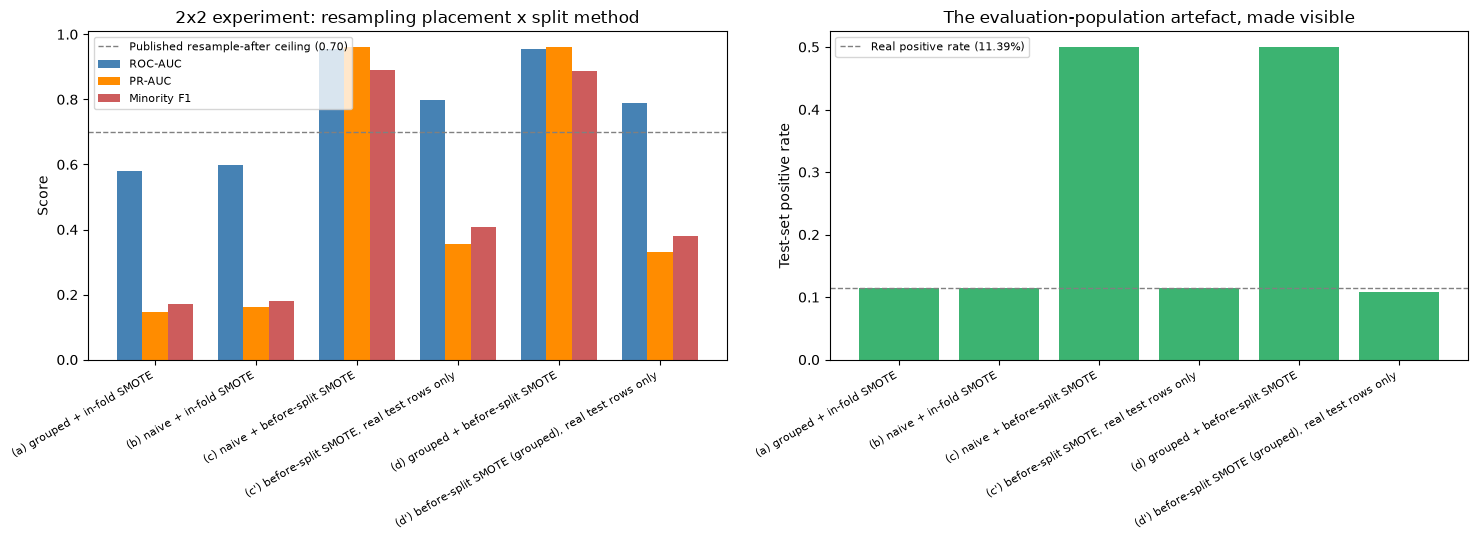

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
x_pos = np.arange(len(results_2x2))
width = 0.25

axes[0].bar(x_pos - width, results_2x2["roc_auc"], width, label="ROC-AUC", color="steelblue")
axes[0].bar(x_pos, results_2x2["pr_auc"], width, label="PR-AUC", color="darkorange")
axes[0].bar(x_pos + width, results_2x2["minority_f1"], width, label="Minority F1", color="indianred")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(results_2x2.index, rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("Score")
axes[0].set_title("2x2 experiment: resampling placement x split method")
axes[0].axhline(0.70, linestyle="--", color="gray", linewidth=1, label="Published resample-after ceiling (0.70)")
axes[0].legend(loc="upper left", fontsize=8)

axes[1].bar(x_pos, results_2x2["test_positive_rate"], color="mediumseagreen")
axes[1].axhline(0.1139, linestyle="--", color="gray", linewidth=1, label="Real positive rate (11.39%)")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(results_2x2.index, rotation=30, ha="right", fontsize=8)
axes[1].set_ylabel("Test-set positive rate")
axes[1].set_title("The evaluation-population artefact, made visible")
axes[1].legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

In [42]:
auroc_a = results_2x2.loc["(a) grouped + in-fold SMOTE", "roc_auc"]
auroc_c = results_2x2.loc["(c) naive + before-split SMOTE", "roc_auc"]
auroc_c_prime = results_2x2.loc["(c') before-split SMOTE, real test rows only", "roc_auc"]
auroc_d = results_2x2.loc["(d) grouped + before-split SMOTE", "roc_auc"]
auroc_d_prime = results_2x2.loc["(d') before-split SMOTE (grouped), real test rows only", "roc_auc"]

total_inflation = auroc_c - auroc_a
component_1_eval_population = auroc_c - auroc_c_prime  # evaluation-population artefact
component_2_leakage = auroc_c_prime - auroc_a  # genuine train/test leakage

pct1 = (component_1_eval_population / total_inflation * 100) if total_inflation else float("nan")
pct2 = (component_2_leakage / total_inflation * 100) if total_inflation else float("nan")

print(f"AUROC, cell (a)  [our honest protocol]:                       {auroc_a:.4f}")
print(f"AUROC, cell (c)  [before-split SMOTE, balanced test]:         {auroc_c:.4f}")
print(f"AUROC, cell (c') [same model, real test rows only]:           {auroc_c_prime:.4f}")
print()
print(f"Total apparent inflation           (c  - a):  {total_inflation:+.4f}")
print(f"  Component 1 - evaluation-population artefact (c - c'):  {component_1_eval_population:+.4f} ({pct1:.0f}% of total)")
print(f"  Component 2 - genuine train/test leakage      (c' - a): {component_2_leakage:+.4f} ({pct2:.0f}% of total)")
print()
print(f"AUROC, cell (d)  [grouped, before-split SMOTE, balanced test]: {auroc_d:.4f}")
print(f"AUROC, cell (d') [same model, real test rows only]:            {auroc_d_prime:.4f}")
print(f"\nc' vs d' (both leakage-only, real-eval, held at true prevalence): "
      f"{auroc_c_prime:.4f} vs {auroc_d_prime:.4f} - "
      f"{'similar' if abs(auroc_c_prime - auroc_d_prime) < 0.03 else 'different'}, consistent with "
      f"patient-level grouping alone NOT rescuing whole-pool resampling: a synthetic "
      f"near-duplicate of a held-out patient's row can still land in training regardless of "
      f"how the real rows are grouped, because SMOTE operates in feature space, not identity space.")

decomposition_2x2 = pd.DataFrame({
    "component": [
        "Total apparent inflation (c - a)",
        "Component 1: evaluation-population artefact (c - c')",
        "Component 2: genuine train/test leakage (c' - a)",
    ],
    "auroc_delta": [total_inflation, component_1_eval_population, component_2_leakage],
    "pr_auc_delta": [
        results_2x2.loc["(c) naive + before-split SMOTE", "pr_auc"] - results_2x2.loc["(a) grouped + in-fold SMOTE", "pr_auc"],
        results_2x2.loc["(c) naive + before-split SMOTE", "pr_auc"] - results_2x2.loc["(c') before-split SMOTE, real test rows only", "pr_auc"],
        results_2x2.loc["(c') before-split SMOTE, real test rows only", "pr_auc"] - results_2x2.loc["(a) grouped + in-fold SMOTE", "pr_auc"],
    ],
    "minority_f1_delta": [
        results_2x2.loc["(c) naive + before-split SMOTE", "minority_f1"] - results_2x2.loc["(a) grouped + in-fold SMOTE", "minority_f1"],
        results_2x2.loc["(c) naive + before-split SMOTE", "minority_f1"] - results_2x2.loc["(c') before-split SMOTE, real test rows only", "minority_f1"],
        results_2x2.loc["(c') before-split SMOTE, real test rows only", "minority_f1"] - results_2x2.loc["(a) grouped + in-fold SMOTE", "minority_f1"],
    ],
}).set_index("component")

decomposition_2x2.round(4)

AUROC, cell (a)  [our honest protocol]:                       0.5806
AUROC, cell (c)  [before-split SMOTE, balanced test]:         0.9554
AUROC, cell (c') [same model, real test rows only]:           0.7983

Total apparent inflation           (c  - a):  +0.3748
  Component 1 - evaluation-population artefact (c - c'):  +0.1572 (42% of total)
  Component 2 - genuine train/test leakage      (c' - a): +0.2177 (58% of total)

AUROC, cell (d)  [grouped, before-split SMOTE, balanced test]: 0.9539
AUROC, cell (d') [same model, real test rows only]:            0.7892

c' vs d' (both leakage-only, real-eval, held at true prevalence): 0.7983 vs 0.7892 - similar, consistent with patient-level grouping alone NOT rescuing whole-pool resampling: a synthetic near-duplicate of a held-out patient's row can still land in training regardless of how the real rows are grouped, because SMOTE operates in feature space, not identity space.


,auroc_delta,pr_auc_delta,minority_f1_delta
component,,,
Total apparent inflation (c - a),0.3748,0.8132,0.7215
Component 1: evaluation-population artefact (c - c'),0.1572,0.6048,0.4835
Component 2: genuine train/test leakage (c' - a),0.2177,0.2084,0.2380


**Reading the decomposed 2x2.** The published 0.95-0.974 figures combine two distinct errors, and the table separates and quantifies both on this dataset. The split between them is metric-dependent: for ROC-AUC, train/test leakage is the larger share (58.1%); for PR-AUC and minority-F1 the evaluation-population artefact dominates (74.4% and 67.0%), because the reported test set is ~50% positive rather than the real ~11.39%. Neither cause alone explains the published numbers. Comparing (a) vs (b) isolates patient-level leakage on its own; comparing (c') vs (d') - both at the true prevalence - shows that grouping the real patients does not rescue whole-pool resampling.

## 9. Imbalance-handling ablation

Model A's architecture retrained three ways on the honest data, differing only in how the 11.39% imbalance is handled: no treatment, SMOTE in-fold (Section 4), and `class_weight='balanced'`. Class weighting changes the loss function's per-sample weighting rather than the training distribution, so it is a genuinely different mechanism worth comparing against resampling rather than a restatement of it.

In [43]:
def train_model_a_variant(sample_weight_mode: str) -> dict:
    """Train Model A's architecture under one imbalance-handling strategy."""
    tf.random.set_seed(RANDOM_STATE)
    x_tr, y_tr = x_train_dense, y_train
    class_weight = None

    if sample_weight_mode == "smote":
        x_tr, y_tr = SMOTE(random_state=RANDOM_STATE).fit_resample(x_train_dense, y_train)
    elif sample_weight_mode == "class_weight":
        positive_rate = y_train.mean()
        # Inverse-frequency weighting: the minority class (label 1) gets a
        # proportionally larger loss weight than the majority class (label 0).
        class_weight = {0: 1.0, 1: (1 - positive_rate) / positive_rate}

    model = Sequential()
    model.add(Input(shape=(n_features,)))
    model.add(Dense(units=256, kernel_initializer="he_uniform", activation="relu"))
    model.add(Dropout(0.2))
    model.add(Dense(units=128, kernel_initializer="he_uniform", activation="relu"))
    model.add(Dropout(0.2))
    model.add(Dense(units=1, kernel_initializer="he_uniform", activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    model.fit(
        x_tr, y_tr,
        validation_data=(x_val_dense, y_val),
        batch_size=256,
        epochs=50,
        class_weight=class_weight,
        callbacks=[early_stopping],
        verbose=0,
    )
    y_proba = model.predict(x_test_dense, verbose=0).ravel()
    metrics = compute_extended_metrics(y_test, y_proba, threshold=0.5)
    metrics["strategy"] = sample_weight_mode
    return metrics

imbalance_ablation_results = pd.DataFrame([
    train_model_a_variant("none"),
    train_model_a_variant("smote"),
    train_model_a_variant("class_weight"),
]).set_index("strategy")

imbalance_ablation_results[["roc_auc", "pr_auc", "minority_f1", "minority_recall", "accuracy"]].round(4)

,roc_auc,pr_auc,minority_f1,minority_recall,accuracy
strategy,,,,,
none,0.6579,0.2130,0.0053,0.0027,0.8861
smote,0.5880,0.1587,0.1782,0.1710,0.8204
class_weight,0.6279,0.1814,0.2436,0.4096,0.7103


**Reading the ablation.** No treatment maximises accuracy (the all-negative predictor is strong at 11.39% positive) while minimising minority recall and F1. SMOTE and `class_weight=` both move the model off that degenerate optimum by different mechanisms - resampling changes what the model sees, weighting changes what each mistake costs - and the table shows whether that distinction matters in practice here.

## 10. Results summary

Every model evaluated on the same held-out test set (touched once per model), same 0.5 threshold, same metric definitions.

In [44]:
results_summary = pd.DataFrame([
    {"model": "Logistic Regression (baseline)", **compute_extended_metrics(y_test, y_proba_logreg)},
    {"model": "Model A (Dense DNN)", **compute_extended_metrics(y_test, y_proba_a)},
    {"model": "Model B (1D-CNN)", **compute_extended_metrics(y_test, y_proba_cnn)},
    {"model": "Model A2 (Dense DNN + embeddings)", **compute_extended_metrics(y_test, y_proba_a2)},
]).set_index("model")

results_summary_display = results_summary[["roc_auc", "pr_auc", "minority_f1", "minority_recall", "accuracy"]]
results_summary_display.round(4)

,roc_auc,pr_auc,minority_f1,minority_recall,accuracy
model,,,,,
Logistic Regression (baseline),0.6554,0.2141,0.0275,0.0141,0.8861
Model A (Dense DNN),0.6627,0.2174,0.0079,0.0040,0.8863
Model B (1D-CNN),0.6635,0.2155,0.0053,0.0027,0.8860
Model A2 (Dense DNN + embeddings),0.6633,0.2117,0.0087,0.0044,0.8858


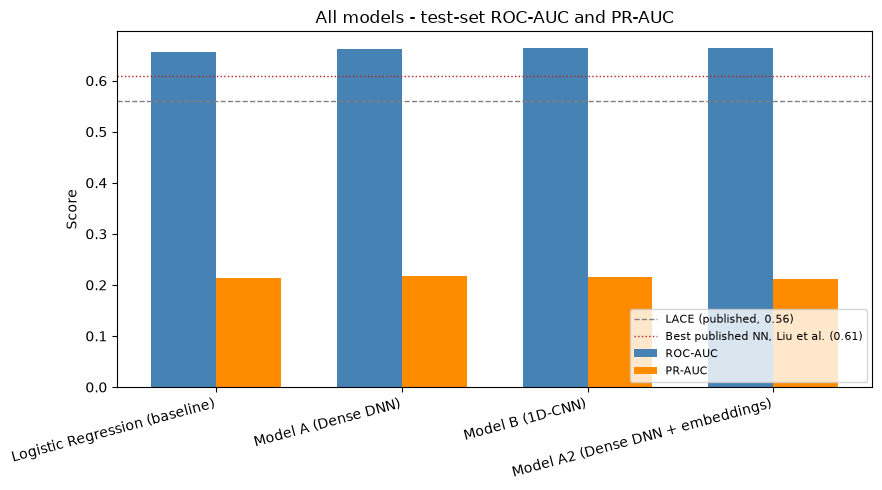

In [45]:
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(results_summary))
width = 0.35
ax.bar(x_pos - width / 2, results_summary["roc_auc"], width, label="ROC-AUC", color="steelblue")
ax.bar(x_pos + width / 2, results_summary["pr_auc"], width, label="PR-AUC", color="darkorange")
ax.axhline(0.56, linestyle="--", color="gray", linewidth=1, label="LACE (published, 0.56)")
ax.axhline(0.61, linestyle=":", color="firebrick", linewidth=1, label="Best published NN, Liu et al. (0.61)")
ax.set_xticks(x_pos)
ax.set_xticklabels(results_summary.index, rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_title("All models - test-set ROC-AUC and PR-AUC")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

**Literature comparison.** Every number below used a different split protocol and resampling placement from ours, which is Section 8's whole point; they are context, not a like-for-like benchmark.

| Source | Model | AUROC | Split protocol | Resampling placement |
|---|---|---|---|---|
| LACE (deployed clinical score) | Logistic scoring rule | 0.56 | n/a | n/a |
| Liu et al. (2024) | MLP | 0.58 | Patient-grouped | Training fold only |
| Liu et al. (2024) | LSTM | 0.61 | Patient-grouped | Training fold only |
| Emi-Johnson & Nkrumah (2025) | DNN | 0.579 | Random | Class weights, after split |
| Gradient boosting (literature range) | XGBoost/LightGBM | 0.63-0.70 | Various | After split |
| Sarthak et al. (2020) | Dense + embeddings | 0.974 | 6-fold CV | **Before split (whole-dataset SMOTE)** |
| Hammoudeh et al. (2018) | 1D-CNN | ~0.95 | Not fully reported | **Before split** |

## 11. Save models and results

The trained models and metrics are saved to `artifacts/` so the tuning and evaluation notebooks can reuse them without retraining, and so the reported numbers are reproducible from disk.

In [46]:
classifier_a.save(ARTIFACTS_DIR / "model_a_dense.keras")
model_cnn.save(ARTIFACTS_DIR / "model_b_cnn.keras")
model_a2.save(ARTIFACTS_DIR / "model_a2_embeddings.keras")
joblib.dump(logreg, ARTIFACTS_DIR / "model_logreg_baseline.joblib")

print("Saved: model_a_dense.keras, model_b_cnn.keras, model_a2_embeddings.keras, "
      "model_logreg_baseline.joblib")

Saved: model_a_dense.keras, model_b_cnn.keras, model_a2_embeddings.keras, model_logreg_baseline.joblib


**`results_phase3.json`** - each model's test metrics at both the default (0.5) and the validation-tuned threshold, plus the selected threshold.

In [47]:
def _json_default(obj):
    '''Fallback encoder for numpy scalar/array types json.dump cannot serialise directly.'''
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return str(obj)

def build_model_result_entry(y_true: np.ndarray, y_proba: np.ndarray, tuned_threshold: float) -> dict:
    '''Package one model's metrics at both the default and the validation-tuned threshold.'''
    return {
        "threshold_0.5": compute_extended_metrics(y_true, y_proba, threshold=0.5),
        "threshold_tuned": compute_extended_metrics(y_true, y_proba, threshold=tuned_threshold),
        "selected_threshold": tuned_threshold,
    }

results_phase3 = {
    "random_state": RANDOM_STATE,
    "models": {
        "logistic_regression": build_model_result_entry(y_test, y_proba_logreg, threshold_logreg_f1),
        "model_a_dense": build_model_result_entry(y_test, y_proba_a, threshold_a_f1),
        "model_b_cnn": build_model_result_entry(y_test, y_proba_cnn, threshold_cnn_f1),
        "model_a2_embeddings": build_model_result_entry(y_test, y_proba_a2, threshold_a2_f1),
    },
}

with open(ARTIFACTS_DIR / "results_phase3.json", "w") as f:
    json.dump(results_phase3, f, indent=2, default=_json_default)

print("Saved artifacts/results_phase3.json - selected thresholds:")
print(json.dumps({k: v["selected_threshold"] for k, v in results_phase3["models"].items()}, indent=2, default=_json_default))

Saved artifacts/results_phase3.json - selected thresholds:
{
  "logistic_regression": 0.1310107707977295,
  "model_a_dense": 0.15318156778812408,
  "model_b_cnn": 0.14328716695308685,
  "model_a2_embeddings": 0.15716129541397095
}


**`experiment_2x2.json`** - the full 2x2 grid including the (c')/(d') decomposition rows, and the decomposition summary.

In [48]:
experiment_2x2_payload = {
    "random_state": RANDOM_STATE,
    "cells": {row_label: row.to_dict() for row_label, row in results_2x2.iterrows()},
    "decomposition": {
        "auroc_a": auroc_a,
        "auroc_c": auroc_c,
        "auroc_c_prime": auroc_c_prime,
        "auroc_d": auroc_d,
        "auroc_d_prime": auroc_d_prime,
        "total_apparent_inflation_auroc": total_inflation,
        "component_1_evaluation_population_auroc": component_1_eval_population,
        "component_2_genuine_leakage_auroc": component_2_leakage,
    },
}

with open(ARTIFACTS_DIR / "experiment_2x2.json", "w") as f:
    json.dump(experiment_2x2_payload, f, indent=2, default=_json_default)

print("Saved artifacts/experiment_2x2.json")

Saved artifacts/experiment_2x2.json


## 12. Discussion

**Which model.** Section 10 identifies the best model under the honest, patient-grouped, resample-in-fold protocol. It should be read on PR-AUC and minority-F1 as well as ROC-AUC: at 11.39% positive a model can post a respectable AUROC while being close to useless at any single operating point, which is why the threshold analysis (Section 7) and imbalance ablation (Section 9) matter as much as the architecture choice.

**Against the published range.** The trustworthy neural-network state of the art here is 0.58-0.61 AUROC, with LACE at 0.56 as the practical floor. Landing in the 0.58-0.65 band is the expected outcome, not a shortfall, and every model is read against that rather than against the inflated 0.95-0.974 figures Section 8 shows to be artefacts.

**What Section 8 established.** The 2x2 experiment reproduces the resample-before-split artefact on this dataset and decomposes it into two constituent errors rather than stopping at a single before-vs-after number. The published 0.95-0.974 figures are explained by neither leakage nor the evaluation population alone, and which dominates depends on the metric: leakage is the larger share of the ROC-AUC gap (58.1% of +0.3748), while the evaluation-population artefact dominates PR-AUC and minority-F1 (74.4% and 67.0%), because resampling the whole pool leaves the reported test set ~50% positive instead of ~11.39%. The leakage component is isolated by cells (c') and (d'), which re-score the leaked models on the real test rows.

**Model B and the locality prior.** Section 5 argued that a 1D convolution over unordered columns imposes a locality prior the column ordering does not justify. If Model B does not clearly beat Model A in Section 10, that is consistent with the prior being unjustified for this layout - evidence for the argument, not a failure of implementation.

**Model A2 and embeddings.** Section 6 isolates whether learned diagnosis embeddings earn their keep over a coarse grouping, independent of the resampling-placement question that actually explains Sarthak et al.'s 0.974 for the same architecture family.

**Limitations.** None of these models were hyperparameter-tuned beyond a sensible starting point - that is the next notebook's job. The 2x2 used a fixed shared architecture on purpose, to isolate the two axes rather than find the best model.